# Data Understanding
Objectif: explorer la structure, les colonnes et la qualite initiale des donnees.

In [1]:
import pandas as pd
from pathlib import Path

data_dir = Path("..") / "data" / "archive"
list(data_dir.iterdir()) if data_dir.exists() else []

[WindowsPath('../data/archive/bridge_job_skills.csv'),
 WindowsPath('../data/archive/dim_company.csv'),
 WindowsPath('../data/archive/dim_country.csv'),
 WindowsPath('../data/archive/dim_platform.csv'),
 WindowsPath('../data/archive/dim_skill.csv'),
 WindowsPath('../data/archive/fact_job_postings.csv')]

In [3]:
%pip install pandas


   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.6 MB 11.8 MB/s eta 0:00:01
   ------------------ --------------------- 4.5/9.6 MB 11.3 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.6 MB 11.4 MB/s eta 0:00:01
   -------------------------------------- - 9.2/9.6 MB 11.5 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 9.9 MB/s  0:00:00
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ------- -------------------------------- 2.4/12.6 MB 11.8 MB/s eta 0:00:01
   --------------- ------------------------ 5.0/12.6 MB 11.8 MB/s eta 0:00:01
   ----------------------- ---------------- 7.3/12.6 MB 11.8 MB/s eta 0:00:01
   ------------------------------- -------- 10.0/12.6 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------  12.3/12.6 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 12.6/12.6 MB 10.3 MB/s  0:00:01

   --------


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
offres = pd.read_csv(data_dir / "fact_job_postings.csv")
offres.head()

,job_id,job_title,company,country,region,platform,experience_level,employment_type,salary_min_usd,salary_max_usd,remote_option,posting_date,applicants_estimate
0,JOB-1,Senior Data Engineer,Netflix,Spain,Europe,Wellfound,Lead,Part-time,163731,171017,Hybrid,52:59.3,472
1,JOB-2,Data Engineer,Snowflake,India,Asia,Indeed,Mid,Contract,145213,153462,Hybrid,52:59.3,500
2,JOB-3,Business Intelligence Analyst,IBM,Netherlands,Europe,Monster,Entry,Contract,87206,121991,Onsite,52:59.3,34
3,JOB-4,Data Scientist,Nvidia,Netherlands,Europe,Indeed,Lead,Full-time,104392,130952,Remote,52:59.3,26
4,JOB-5,AI Engineer,Netflix,Germany,Europe,Company Site,Mid,Part-time,162767,186131,Hybrid,52:59.3,303


In [3]:
offres.shape

(55000, 13)

In [4]:
offres.info()

<class 'pandas.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               55000 non-null  str  
 1   job_title            55000 non-null  str  
 2   company              55000 non-null  str  
 3   country              55000 non-null  str  
 4   region               55000 non-null  str  
 5   platform             55000 non-null  str  
 6   experience_level     55000 non-null  str  
 7   employment_type      55000 non-null  str  
 8   salary_min_usd       55000 non-null  int64
 9   salary_max_usd       55000 non-null  int64
 10  remote_option        55000 non-null  str  
 11  posting_date         55000 non-null  str  
 12  applicants_estimate  55000 non-null  int64
dtypes: int64(3), str(10)
memory usage: 5.5 MB


In [5]:
offres.head()

,job_id,job_title,company,country,region,platform,experience_level,employment_type,salary_min_usd,salary_max_usd,remote_option,posting_date,applicants_estimate
0,JOB-1,Senior Data Engineer,Netflix,Spain,Europe,Wellfound,Lead,Part-time,163731,171017,Hybrid,52:59.3,472
1,JOB-2,Data Engineer,Snowflake,India,Asia,Indeed,Mid,Contract,145213,153462,Hybrid,52:59.3,500
2,JOB-3,Business Intelligence Analyst,IBM,Netherlands,Europe,Monster,Entry,Contract,87206,121991,Onsite,52:59.3,34
3,JOB-4,Data Scientist,Nvidia,Netherlands,Europe,Indeed,Lead,Full-time,104392,130952,Remote,52:59.3,26
4,JOB-5,AI Engineer,Netflix,Germany,Europe,Company Site,Mid,Part-time,162767,186131,Hybrid,52:59.3,303


In [6]:
offres.isna().sum()

job_id                 0
job_title              0
company                0
country                0
region                 0
platform               0
experience_level       0
employment_type        0
salary_min_usd         0
salary_max_usd         0
remote_option          0
posting_date           0
applicants_estimate    0
dtype: int64

In [7]:
offres.duplicated().sum(), offres["job_id"].duplicated().sum()

(np.int64(0), np.int64(0))

In [8]:
offres["job_title"].value_counts()


job_title
Business Intelligence Analyst    5651
AI Engineer                      5595
Senior Data Engineer             5584
Senior Data Scientist            5572
Analytics Engineer               5534
Data Analyst                     5506
Data Engineer                    5420
Data Scientist                   5408
Machine Learning Engineer        5382
Senior Data Analyst              5348
Name: count, dtype: int64

In [9]:
offres.sample(5, random_state=42)

,job_id,job_title,company,country,region,platform,experience_level,employment_type,salary_min_usd,salary_max_usd,remote_option,posting_date,applicants_estimate
34191,JOB-34192,Senior Data Scientist,IBM,UAE,Middle East,Indeed,Lead,Part-time,112109,138206,Remote,52:59.6,362
23679,JOB-23680,Business Intelligence Analyst,Netflix,Netherlands,Europe,Glassdoor,Entry,Full-time,87482,98837,Hybrid,52:59.5,480
44684,JOB-44685,Data Scientist,Amazon,United States,North America,Wellfound,Senior,Full-time,121988,131463,Remote,52:59.7,405
11335,JOB-11336,Data Scientist,Nvidia,Spain,Europe,LinkedIn,Senior,Full-time,131596,161522,Onsite,52:59.4,302
22691,JOB-22692,Data Engineer,Accenture,Singapore,Asia,LinkedIn,Mid,Contract,178308,190535,Remote,52:59.5,113


In [10]:
offres.columns

Index(['job_id', 'job_title', 'company', 'country', 'region', 'platform',
       'experience_level', 'employment_type', 'salary_min_usd',
       'salary_max_usd', 'remote_option', 'posting_date',
       'applicants_estimate'],
      dtype='str')

In [11]:
offres.dtypes

job_id                   str
job_title                str
company                  str
country                  str
region                   str
platform                 str
experience_level         str
employment_type          str
salary_min_usd         int64
salary_max_usd         int64
remote_option            str
posting_date             str
applicants_estimate    int64
dtype: object

In [12]:
offres.describe()

,salary_min_usd,salary_max_usd,applicants_estimate
count,55000.000000,55000.000000,55000.000000
mean,111988.403436,131994.359127,302.393236
std,36760.585439,37732.318058,172.261001
min,45001.000000,50249.000000,5.000000
25%,81729.000000,101241.250000,154.000000
50%,113040.000000,132898.000000,303.000000
75%,141723.500000,161854.750000,451.000000
max,179995.000000,214687.000000,600.000000


In [13]:
offres[["job_title", "experience_level", "employment_type", "remote_option"]].nunique()

job_title           10
experience_level     4
employment_type      3
remote_option        3
dtype: int64

In [14]:
offres["experience_level"].value_counts(dropna=False)
offres["employment_type"].value_counts(dropna=False)
offres["remote_option"].value_counts(dropna=False)

remote_option
Onsite    18587
Hybrid    18226
Remote    18187
Name: count, dtype: int64

In [15]:
offres[["salary_min_usd", "salary_max_usd", "applicants_estimate"]].agg(["min", "max"])

,salary_min_usd,salary_max_usd,applicants_estimate
min,45001,50249,5
max,179995,214687,600


In [16]:
offres[["salary_min_usd", "salary_max_usd", "applicants_estimate"]].quantile([0.25, 0.5, 0.75])

,salary_min_usd,salary_max_usd,applicants_estimate
0.25,81729.0,101241.25,154.0
0.50,113040.0,132898.00,303.0
0.75,141723.5,161854.75,451.0


In [17]:
(offres["salary_min_usd"] > offres["salary_max_usd"]).sum()

np.int64(0)

In [18]:
offres["posting_date"].value_counts().head(10)

posting_date
52:59.5    11580
52:59.6    11156
52:59.7    11136
52:59.8     8393
52:59.3     7206
52:59.4     5529
Name: count, dtype: int64

In [19]:
colonnes_num = ["salary_min_usd", "salary_max_usd", "applicants_estimate"]

offres[colonnes_num].agg(["mean", "median", "min", "max"])

,salary_min_usd,salary_max_usd,applicants_estimate
mean,111988.403436,131994.359127,302.393236
median,113040.000000,132898.000000,303.000000
min,45001.000000,50249.000000,5.000000
max,179995.000000,214687.000000,600.000000


<Axes: >

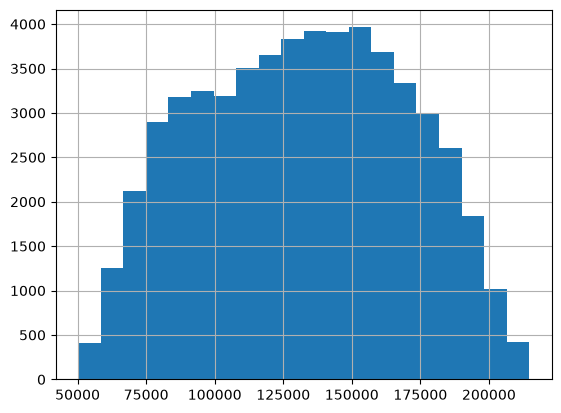

In [20]:
offres["salary_max_usd"].hist(bins=20)

In [21]:
offres["salary_mid_usd"] = (
    offres["salary_min_usd"] + offres["salary_max_usd"]
) / 2

<Axes: title={'center': 'salary_mid_usd'}, xlabel='experience_level'>

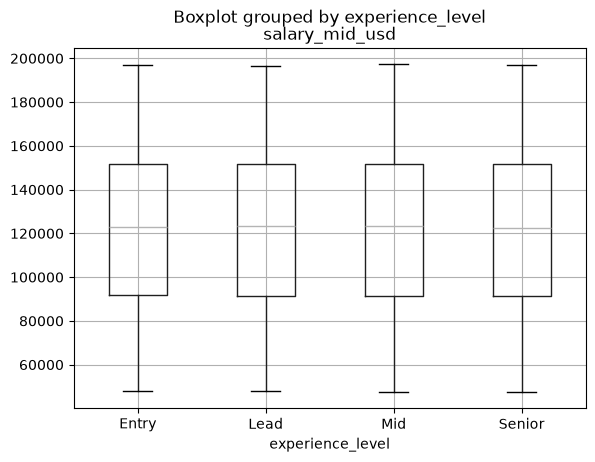

In [22]:
offres.boxplot(column="salary_mid_usd", by="experience_level")

In [23]:
offres["job_title"].value_counts()

job_title
Business Intelligence Analyst    5651
AI Engineer                      5595
Senior Data Engineer             5584
Senior Data Scientist            5572
Analytics Engineer               5534
Data Analyst                     5506
Data Engineer                    5420
Data Scientist                   5408
Machine Learning Engineer        5382
Senior Data Analyst              5348
Name: count, dtype: int64

In [24]:
offres["job_title"].value_counts(normalize=True).mul(100).round(1)

job_title
Business Intelligence Analyst    10.3
AI Engineer                      10.2
Senior Data Engineer             10.2
Senior Data Scientist            10.1
Analytics Engineer               10.1
Data Analyst                     10.0
Data Engineer                     9.9
Data Scientist                    9.8
Machine Learning Engineer         9.8
Senior Data Analyst               9.7
Name: proportion, dtype: float64

In [25]:
offres.groupby("experience_level")["salary_mid_usd"].median().sort_values()

experience_level
Senior    122627.25
Entry     122824.00
Lead      123335.75
Mid       123338.50
Name: salary_mid_usd, dtype: float64

In [26]:
pd.crosstab(offres["experience_level"], offres["remote_option"])

remote_option,Hybrid,Onsite,Remote
experience_level,,,
Entry,4610,4690,4577
Lead,4568,4627,4507
Mid,4507,4628,4514
Senior,4541,4642,4589


<Axes: xlabel='salary_mid_usd', ylabel='applicants_estimate'>

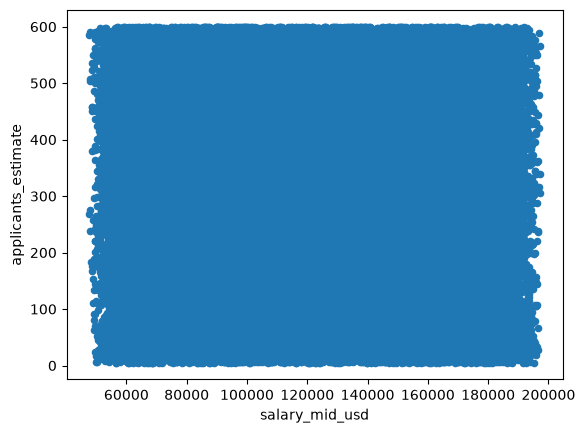

In [27]:
offres.plot.scatter(x="salary_mid_usd", y="applicants_estimate")

In [28]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
